In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file, skiprows=2).assign(Source=os.path.basename(file)) for file in files]




In [3]:
df = pd.concat(dfs, ignore_index=True)


In [4]:
df.head()

,Date,product,Cumulative Selected Measure,Source
0,2018-03-13,Florence,356,google.xlsx
1,2018-03-14,Florence,2720,google.xlsx
2,2018-03-15,Florence,4017,google.xlsx
3,2018-03-16,Florence,4655,google.xlsx
4,2018-03-17,Florence,5074,google.xlsx


In [5]:
df.Source.unique()

array(['google.xlsx', 'nintendo.xlsx', 'playstation.xlsx', 'epic.xlsx',
       'gog.xlsx', 'steam.xlsx', 'xbox.xlsx', 'apple.xlsx', 'humble.xlsx'],
      dtype=object)

In [6]:
file_name = 'xbox'

In [7]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"
dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [8]:
df_combined = df.query(f"Source =='{file_name}.xlsx'")
#df_combined['release_date'] = df_combined['product'].map(release_dict)

In [9]:
df_combined

,Date,product,Cumulative Selected Measure,Source
192038,2022-04-04,A Memoir Blue,7,xbox.xlsx
192039,2022-04-04,Ashen,5,xbox.xlsx
192040,2022-04-04,Ashen Definitive Edition,1,xbox.xlsx
192041,2022-04-04,Donut County,8,xbox.xlsx
192042,2022-04-04,I Am Dead,1,xbox.xlsx
...,...,...,...,...
217920,2025-06-05,Thirsty Suitors,336,xbox.xlsx
217921,2025-06-05,to a T,617,xbox.xlsx
217922,2025-06-05,Twelve Minutes,25657,xbox.xlsx
217923,2025-06-05,Wanderstop,2604,xbox.xlsx


In [10]:
df_combined["percent_of_max"] = df_combined["Cumulative Selected Measure"] / df_combined.groupby("product")["Cumulative Selected Measure"].transform("max")
#df_combined

In [11]:
df_combined['release_date'] = pd.to_datetime(df_combined['Date'])

In [12]:
df_combined['release_date'] = df_combined.groupby('product')['release_date'].transform('min')

In [13]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df_combined["Weeks_from_Release"] = (df_combined["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

df_combined = df_combined.query("0 <= Weeks_from_Release <=156")

df_combined = df_combined.query("'1/1/2015' <= release_date <= '1/1/2024'")

df_combined = df_combined.groupby(["product", "Weeks_from_Release"], as_index=False)["Cumulative Selected Measure"].max()

In [14]:
title_exclusion = [
'Stray','Outer Wilds',
    'Outer Wilds - Archaeologist Edition BUNDLE',
    
'What Remains of Edith Finch',
    'Cocoon', 'Donut County', 'Gorogoa'
]

In [15]:
title_exclusion = ['Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition',]

In [16]:
title_exclusion = [
'Stray','Outer Wilds',]

In [17]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Cocoon', 'Donut County', 'Gorogoa',
       'Hindsight', 'I Am Dead', 'Kentucky Route Zero: TV Edition',
       'Last Stop', 'Maquette', 'Outer Wilds',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC', 'Sayonara Wild Hearts',
       'Solar Ash', 'Stray', 'Telling Lies', 'The Artful Escape',
       'The Pathless', 'Thirsty Suitors', 'Twelve Minutes',
       'What Remains of Edith Finch'], dtype=object)

In [18]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure
0,A Memoir Blue,1,58
1,A Memoir Blue,2,91
2,A Memoir Blue,3,122
3,A Memoir Blue,4,137
4,A Memoir Blue,5,167
...,...,...,...
3360,What Remains of Edith Finch,152,75907
3361,What Remains of Edith Finch,153,76052
3362,What Remains of Edith Finch,154,76189
3363,What Remains of Edith Finch,155,76311


In [19]:
df_combined = df_combined.query("product !=@title_exclusion")

In [20]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC',
       'Ashen Definitive Edition', 'Cocoon', 'Donut County', 'Gorogoa',
       'Hindsight', 'I Am Dead', 'Kentucky Route Zero: TV Edition',
       'Last Stop', 'Maquette',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC', 'Sayonara Wild Hearts',
       'Solar Ash', 'Telling Lies', 'The Artful Escape', 'The Pathless',
       'Thirsty Suitors', 'Twelve Minutes', 'What Remains of Edith Finch'],
      dtype=object)

In [21]:
#pd.set_option("display.max_rows", None)


df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]
df_combined["daily_delta"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].pct_change().fillna(0)
df_combined.query("product=='Maquette' & Weeks_from_Release <=52")


,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta
1623,Maquette,1,75,1589,0.047199,0.000000
1624,Maquette,2,106,1589,0.066709,0.413333
1625,Maquette,3,112,1589,0.070485,0.056604
1626,Maquette,4,123,1589,0.077407,0.098214
1627,Maquette,5,129,1589,0.081183,0.048780
1628,Maquette,6,133,1589,0.083700,0.031008
1629,Maquette,7,135,1589,0.084959,0.015038
1630,Maquette,8,141,1589,0.088735,0.044444
1631,Maquette,9,146,1589,0.091882,0.035461
1632,Maquette,10,151,1589,0.095028,0.034247


In [22]:
audit = df_combined.query("Weeks_from_Release <=52").pivot(index='product', columns='Weeks_from_Release',values='daily_delta').reset_index()
audit.sort_values(by=4,ascending=False)

Weeks_from_Release,product,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
16,Telling Lies,0.0,0.600000,0.000000,0.750000,0.071429,0.133333,0.117647,12.526316,0.715953,...,0.044830,0.066436,0.016223,0.012771,0.012610,0.008095,0.009265,0.012852,0.010876,0.012552
14,Sayonara Wild Hearts,0.0,2.200000,0.687500,0.629630,0.181818,0.269231,4.348485,0.223796,0.034722,...,0.006757,0.006711,0.005238,0.013738,0.009346,0.004167,0.005071,0.004128,0.004568,0.009550
2,Ashen - Nightstorm Isle DLC,0.0,3.000000,1.000000,0.500000,0.833333,0.181818,0.115385,0.034483,0.100000,...,0.002695,0.002688,0.004021,0.002670,0.001332,0.001330,0.001328,0.000000,0.000000,0.001326
10,Last Stop,0.0,0.200000,0.000000,0.500000,3.333333,0.846154,0.000000,0.013889,0.013699,...,0.005204,0.003698,0.005895,0.004396,0.005835,0.004351,0.003610,0.002158,0.002154,0.000716
20,Twelve Minutes,0.0,0.823529,0.419355,0.477273,0.184615,2.324675,0.132812,0.055172,0.049020,...,0.021666,0.021206,0.014833,0.019399,0.013295,0.013121,0.014982,0.015011,0.012078,0.187530
5,Donut County,0.0,1.000000,0.600000,0.351562,0.254335,0.198157,0.138462,1.824324,0.616029,...,0.052081,0.087439,0.064880,0.047743,0.054528,0.034352,0.029540,0.032428,0.029765,0.030501
3,Ashen Definitive Edition,0.0,0.590909,0.428571,0.340000,30.417910,0.235154,0.008846,0.007244,0.007949,...,0.000864,0.001129,0.000597,0.000796,0.000729,0.000993,0.000529,0.001322,0.000990,0.000858
21,What Remains of Edith Finch,0.0,1.444444,0.563636,0.325581,0.188596,0.118081,0.132013,1.988338,0.538537,...,0.009539,0.010031,0.009098,0.008191,0.009069,0.007365,0.008364,0.009339,0.007122,0.006468
13,Outer Wilds - Echoes of the Eye DLC,0.0,1.066116,0.470000,0.310204,0.209761,0.193133,0.181295,0.133374,0.124664,...,0.007363,0.005786,0.004239,0.004623,0.005102,0.003882,0.028158,0.009257,0.004682,0.003994
1,Ashen,0.0,0.823529,0.516129,0.276596,5.916667,0.320482,0.040146,0.024561,0.020548,...,0.003624,0.001805,0.001201,0.001000,0.001798,0.001197,0.001594,0.001591,0.001986,0.001387


In [23]:
# Flatten the DataFrame and filter values > 5
filtered = audit.set_index('product').stack()
high_vals = filtered[filtered > 1]

# Sort descending to find the highest ones
top_high_vals = high_vals.sort_values(ascending=False)

top_high_vals.sort_index(level='product')

product                                     Weeks_from_Release
Ashen                                       5                      5.916667
Ashen - Nightstorm Isle DLC                 2                      3.000000
Ashen Definitive Edition                    5                     30.417910
Donut County                                8                      1.824324
Gorogoa                                     3                      1.285714
                                            11                     3.365854
                                            12                     1.111732
I Am Dead                                   11                     6.812500
                                            12                     1.496000
Kentucky Route Zero: TV Edition             6                      1.235294
Last Stop                                   5                      3.333333
                                            11                     3.066667
Outer Wilds - Archaeologi

In [24]:
platform_df = df_combined.groupby("Weeks_from_Release")[['daily_delta','prop_of_total']].mean()
platform_df['platform'] = file_name

In [25]:
platform_df.query(" Weeks_from_Release <=52")

,daily_delta,prop_of_total,platform
Weeks_from_Release,,,
1,0.000000,0.022253,xbox
2,0.796915,0.030843,xbox
3,0.363660,0.035000,xbox
4,0.282220,0.038797,xbox
5,1.957906,0.046602,xbox
6,0.371511,0.051556,xbox
7,0.376466,0.057260,xbox
8,0.821238,0.063579,xbox
9,0.142072,0.068422,xbox


In [26]:
platform_df.to_csv(f"units/{file_name}_average.csv")

In [27]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta
0,A Memoir Blue,1,58,6614,0.008769,0.000000
1,A Memoir Blue,2,91,6614,0.013759,0.568966
2,A Memoir Blue,3,122,6614,0.018446,0.340659
3,A Memoir Blue,4,137,6614,0.020714,0.122951
4,A Memoir Blue,5,167,6614,0.025249,0.218978
...,...,...,...,...,...,...
3360,What Remains of Edith Finch,152,75907,76452,0.992871,0.001861
3361,What Remains of Edith Finch,153,76052,76452,0.994768,0.001910
3362,What Remains of Edith Finch,154,76189,76452,0.996560,0.001801
3363,What Remains of Edith Finch,155,76311,76452,0.998156,0.001601


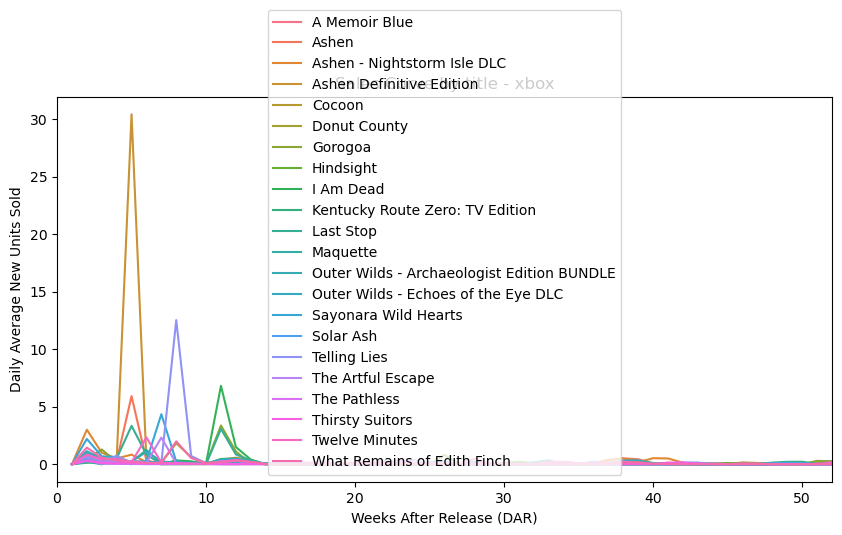

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='daily_delta', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.xlim(0,52)
plt.show()

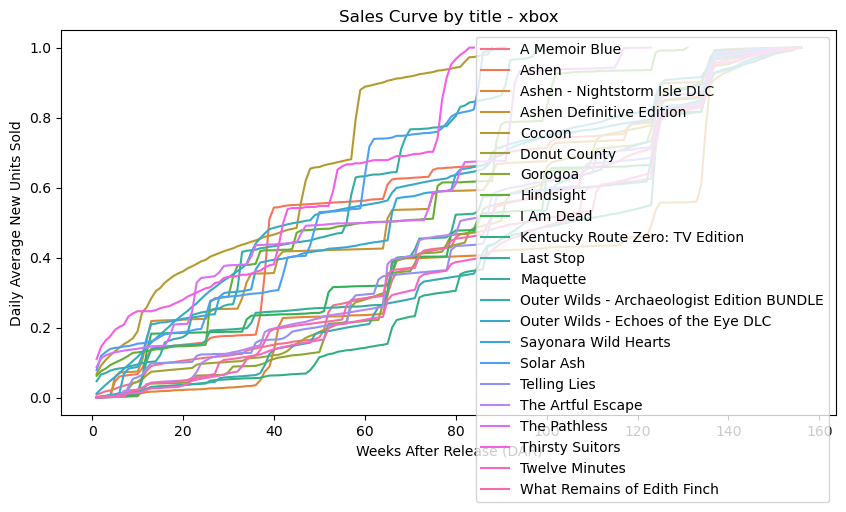

In [29]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

sns.lineplot(data=df_combined, x='Weeks_from_Release', y='prop_of_total', hue='product')
# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title(f"Sales Curve by title - {file_name}")
plt.legend(loc="best")
#plt.tight_layout()# Set legend title
plt.savefig(f"{file_name}.png")
plt.show()

In [30]:
stop

NameError: name 'stop' is not defined

In [ ]:
### Fit the Curve to a model and use this to predict



# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.csv")

# Read all files into DataFrames and add filename column
dfs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]




In [ ]:
files

In [ ]:
av_df = pd.concat(dfs, ignore_index=True)


In [ ]:
platforms = av_df.pivot_table(columns='platform', index='Weeks_from_Release', values='daily_delta').reset_index()

In [ ]:
platforms.to_clipboard()

In [ ]:
platforms.columns[1:]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['apple', 'epic', 'gog', 'google', 'humble', 'nintendo', 'playstation',
       'steam', 'xbox']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='prop_of_total', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.xlim(0)
plt.grid(True)  # Add grid for readability

plt.show()